In [1]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
plt.style.use('default')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Load data
url = "https://raw.githubusercontent.com/diplomadoequipo908-a11y/Proyecto-modulo-5/main/dataset.csv"
raw = pd.read_csv(url)
raw = raw.drop(columns=['Unnamed: 0'])
# Drop duplicates on track_id keep unique tracks.
df = raw.drop_duplicates(subset='track_id').copy().reset_index(drop=True)
print('Raw data:',raw.shape)
print('Unique tracks data:',df.shape)
df.describe()

Raw data: (114000, 20)
Unique tracks data: (89741, 20)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,33.198438,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,20.580824,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Data Dictionary
| Column | Type | Range | Description |
|---|---|---|---|
| `track_id` | String | — | Unique Spotify URI identifier for the track |
| `artists` | String | — | Performing artist name(s) |
| `album_name` | String | — | Album the track belongs to |
| `track_name` | String | — | Title of the track |
| `popularity` | Integer | 0 – 100 | Spotify popularity score (higher = more popular) |
| `duration_ms` | Integer | 0 – 5.2M | Track duration in milliseconds |
| `explicit` | Boolean | True/False | Whether the track has explicit lyrics |
| `danceability` | Float | 0.0 – 1.0 | How suitable a track is for dancing |
| `energy` | Float | 0.0 – 1.0 | Perceptual measure of intensity and activity |
| `key` | Integer | 0 – 11 | Musical key (0=C, 1=C♯, 2=D … 11=B) |
| `loudness` | Float | -49.5 – 4.5 | Overall loudness in decibels (dB) |
| `mode` | Integer | 0 or 1 | Modality — 1 = Major, 0 = Minor |
| `speechiness` | Float | 0.0 – 1.0 | Presence of spoken words in the track |
| `acousticness` | Float | 0.0 – 1.0 | Confidence the track is acoustic |
| `instrumentalness` | Float | 0.0 – 1.0 | Predicts whether a track has no vocals |
| `liveness` | Float | 0.0 – 1.0 | Detects presence of a live audience |
| `valence` | Float | 0.0 – 1.0 | Musical positiveness conveyed by the track |
| `tempo` | Float | 0 – 243 | Estimated tempo in beats per minute (BPM) |
| `time_signature` | Integer | 0 – 5 | Estimated time signature of the track |
| `track_genre` | String | 114 classes | Genre label assigned to the track |

#### For scale purposes, we will use a log transform for duration_ms since most of the features are scales between (0,1)

In [3]:
df['duration_ms'] = np.log1p(
    df['duration_ms']
)

## Null values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
loudness            0
mode                0
key                 0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64


In [5]:
# Fill null values
for col in ['track_name', 'album_name', 'artists']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


# Exploratory Data Analysis
## Popularity distribution

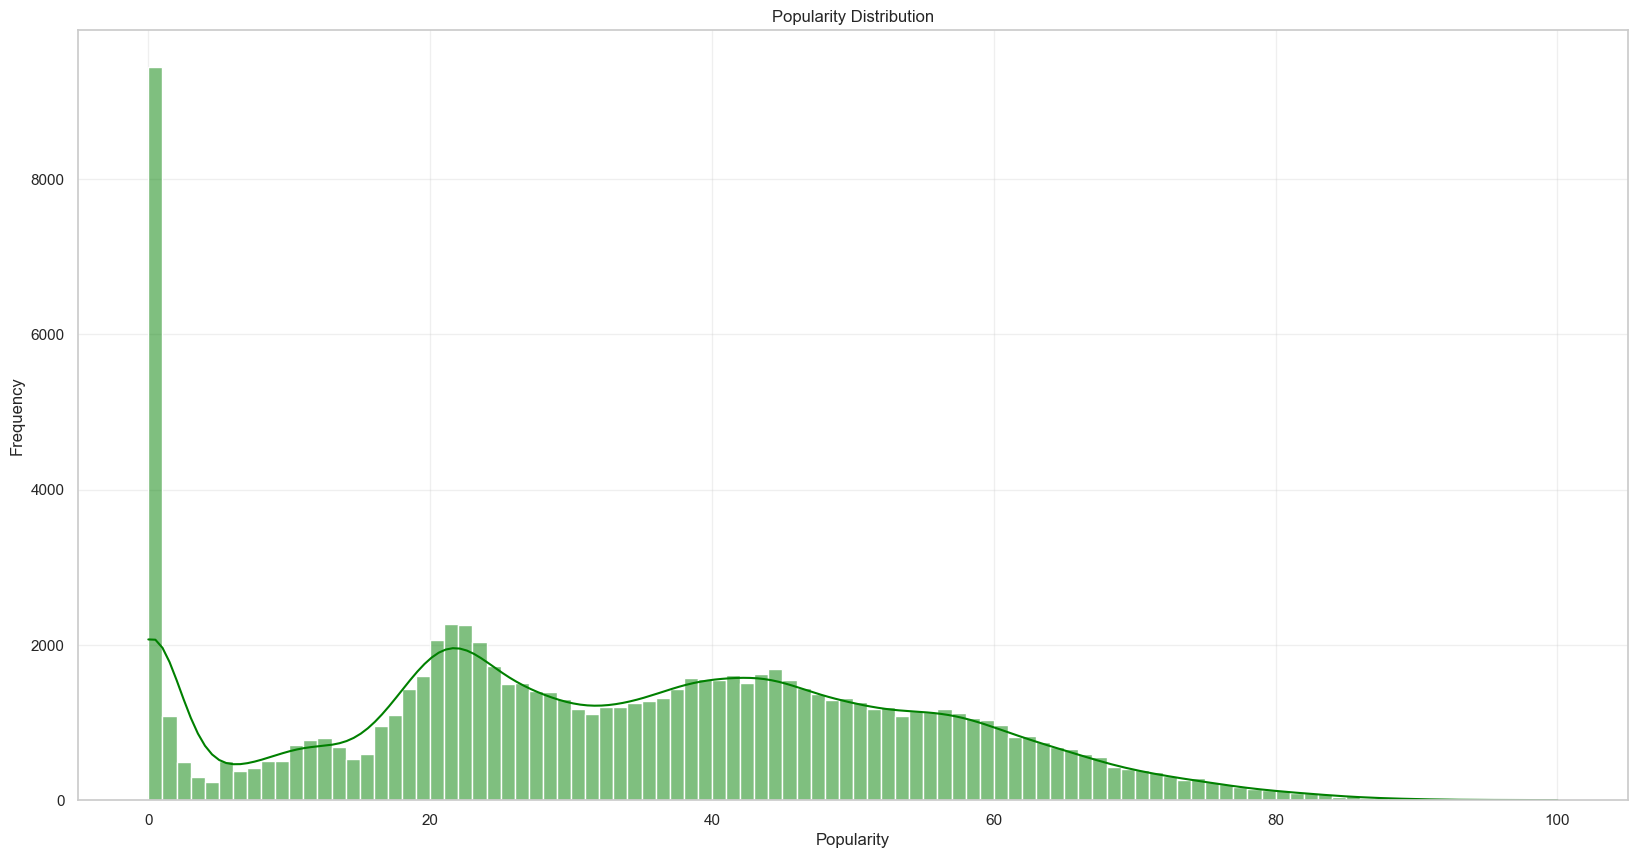

In [6]:
plt.figure(figsize=(20,10))
sns.histplot(df['popularity'], bins=100, kde=True,color='green')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [7]:
print(f"Mean: {df['popularity'].mean():.2f}")
print(f"Median: {df['popularity'].median():.2f}")
print(f"Skewness: {skew(df['popularity']):.3f}")

Mean: 33.20
Median: 33.00
Skewness: 0.071


##### Popularity is approximately symmetric and not dominated by extreme values

#### Popular vs unpopular songs

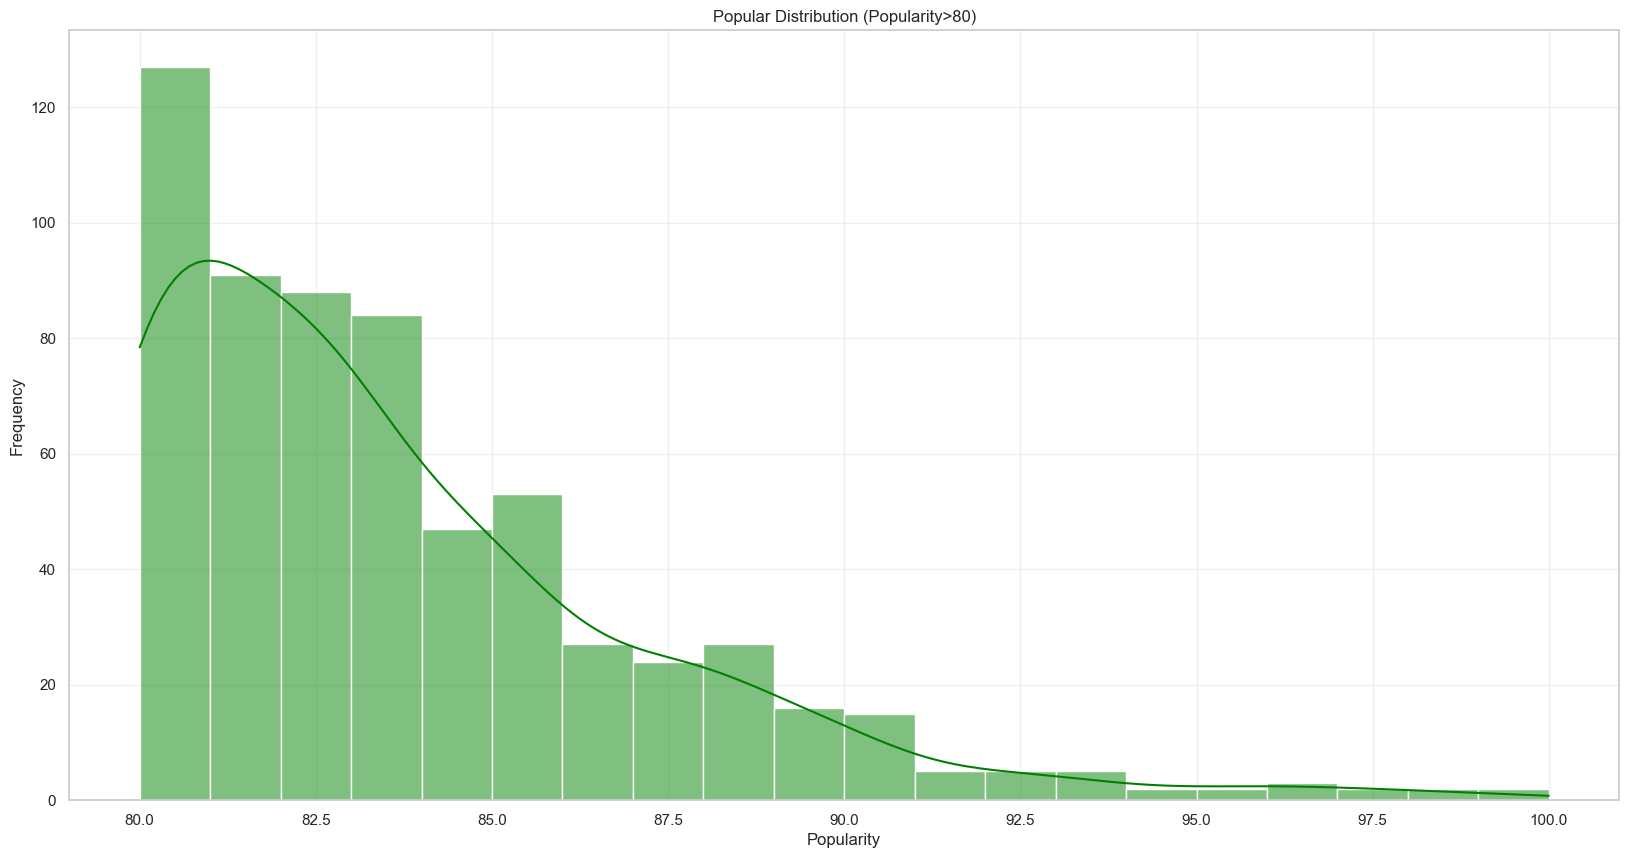

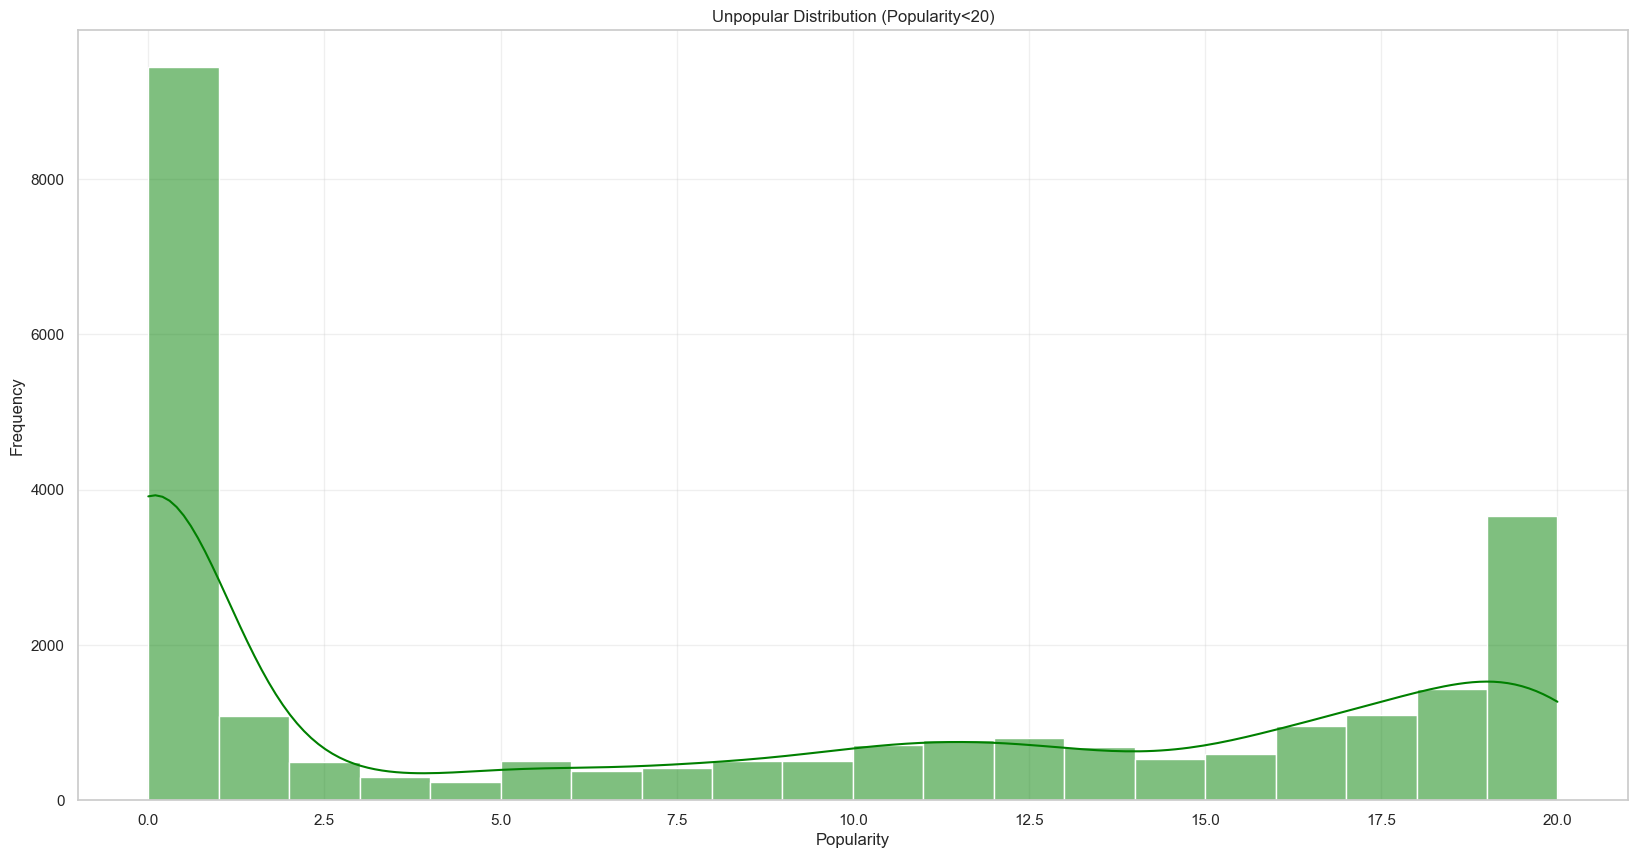

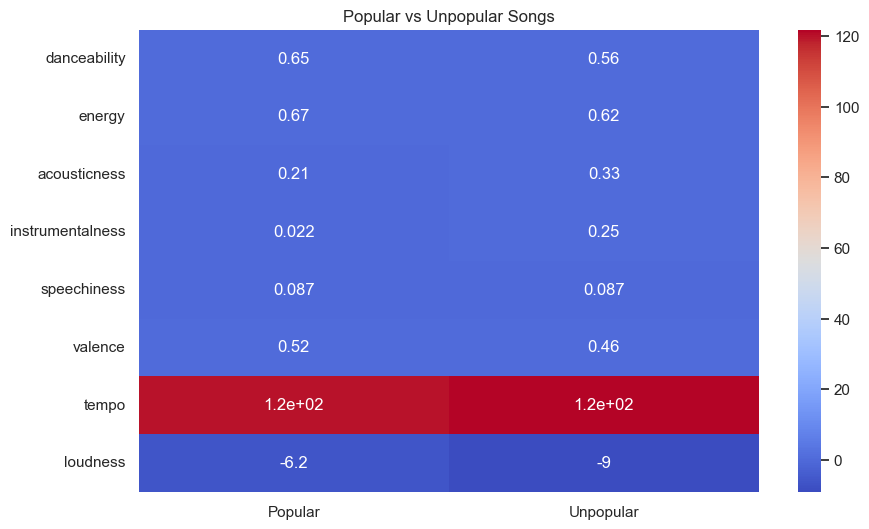

In [17]:
popular = df[df['popularity'] >= 80]

unpopular = df[df['popularity'] <= 20]

plt.figure(figsize=(20,10))
sns.histplot(popular['popularity'], bins=20, kde=True,color='green')
plt.title('Popular Distribution (Popularity>80)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(20,10))
sns.histplot(unpopular['popularity'], bins=20, kde=True,color='green')
plt.title('Unpopular Distribution (Popularity<20)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

comparison = pd.DataFrame({
    'Popular':
        popular.mean(numeric_only=True),

    'Unpopular':
        unpopular.mean(numeric_only=True)
})
features_to_compare = [
    'danceability',
    'energy',
    'acousticness',
    'instrumentalness',
    'speechiness',
    'valence',
    'tempo',
    'loudness'
]
plt.figure(figsize=(10,6))

sns.heatmap(
    comparison.loc[
        features_to_compare
    ],
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Popular vs Unpopular Songs"
)

plt.show()

## Top 20 genres

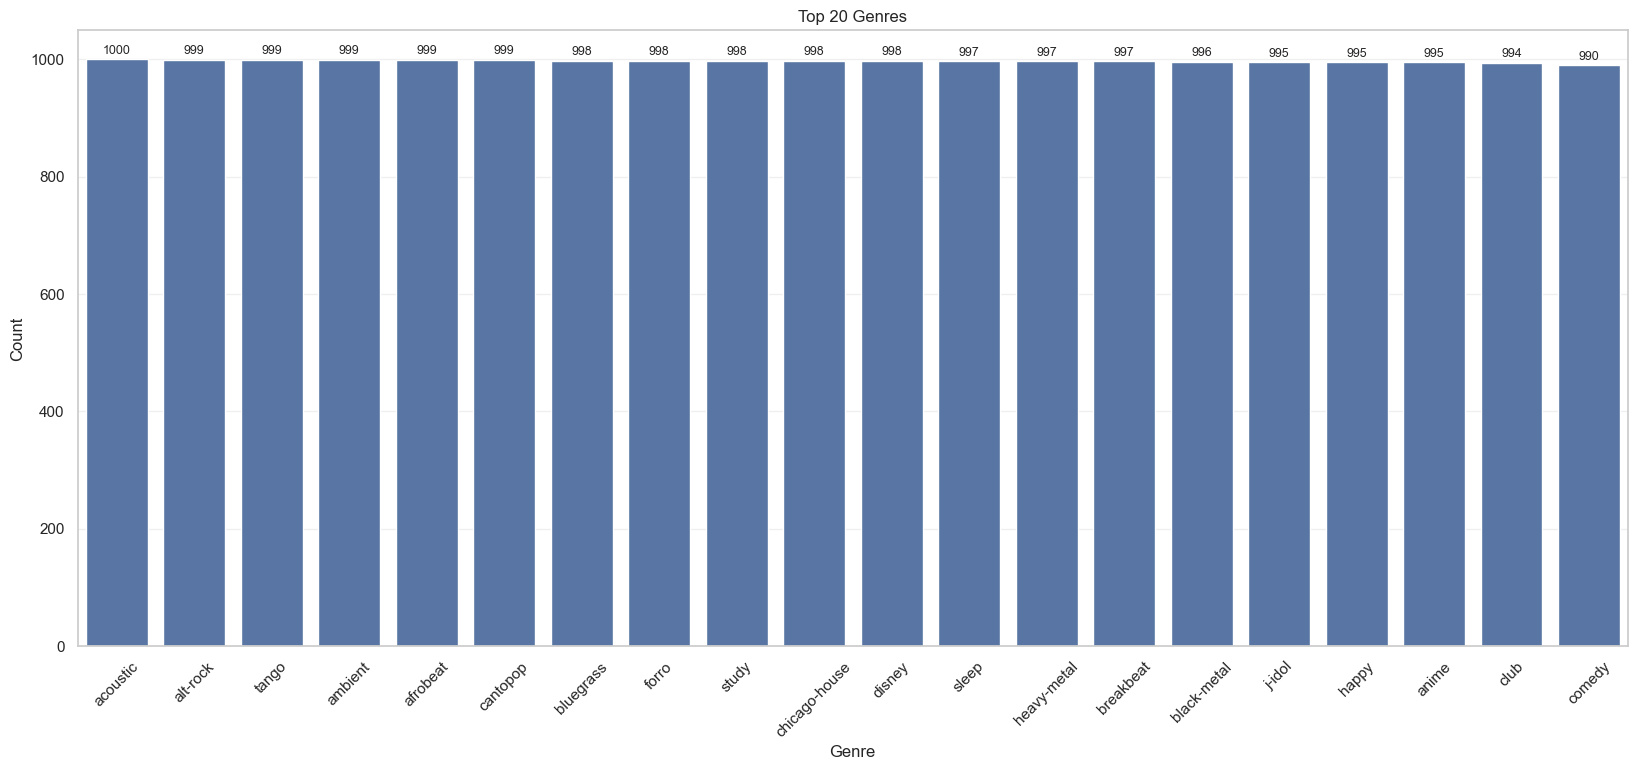

In [9]:
plt.figure(figsize=(20,8))
top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
)
ax = sns.barplot(x=top_genres.index,y=top_genres.values)

for i, v in enumerate(top_genres.values):
    ax.text(
        i,
        v + 10,
        str(v),
        ha='center',
        fontsize=9
    )

plt.title("Top 20 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Average popularity by genres

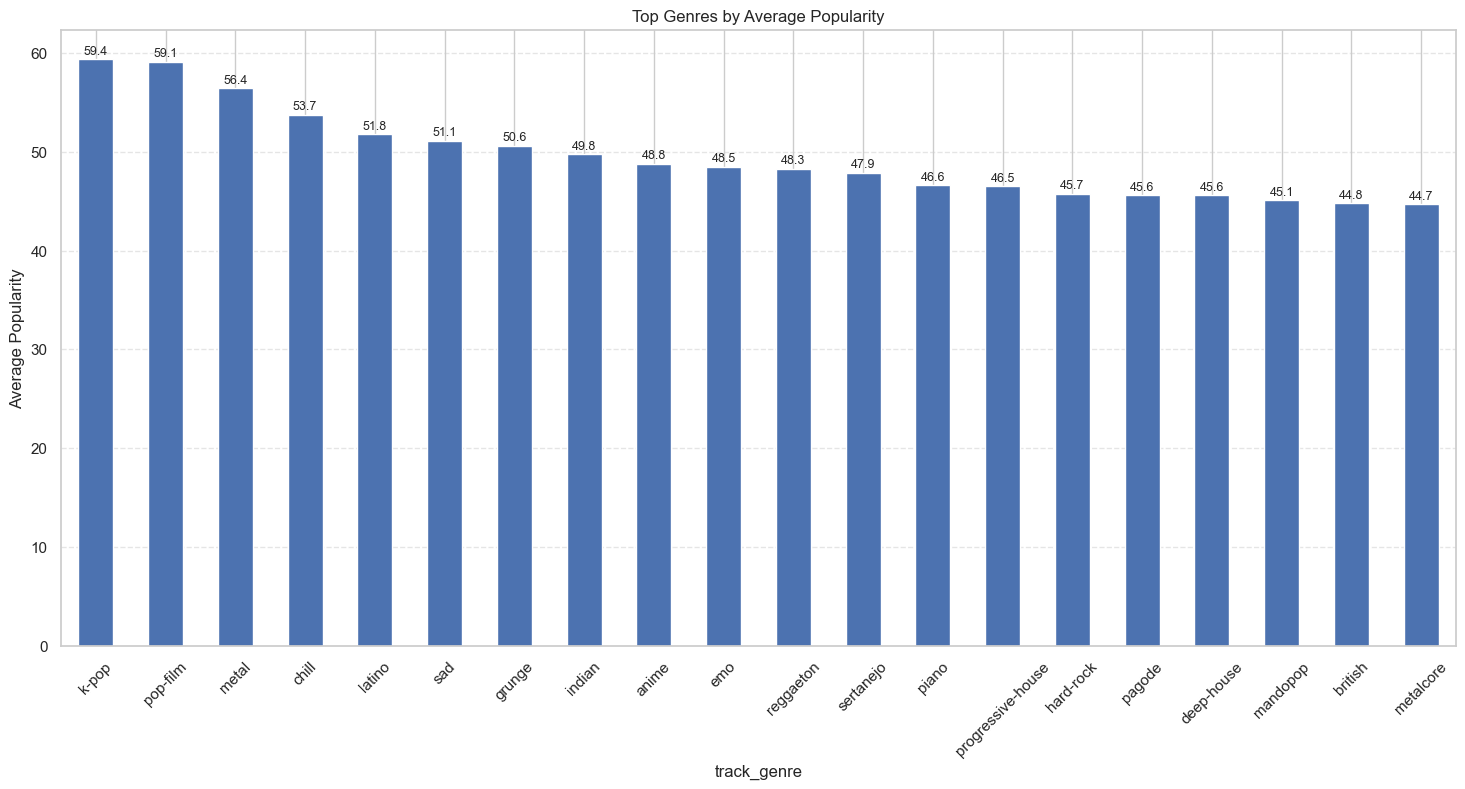

In [10]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
)

top_20 = genre_popularity.head(20)

plt.figure(figsize=(18,8))
ax = top_20.plot(kind='bar')
for i, v in enumerate(top_20.values):
    ax.text(
        i,
        v + 0.5,
        f'{v:.1f}',
        ha='center',
        fontsize=9
    )
plt.title("Top Genres by Average Popularity")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)
plt.show()

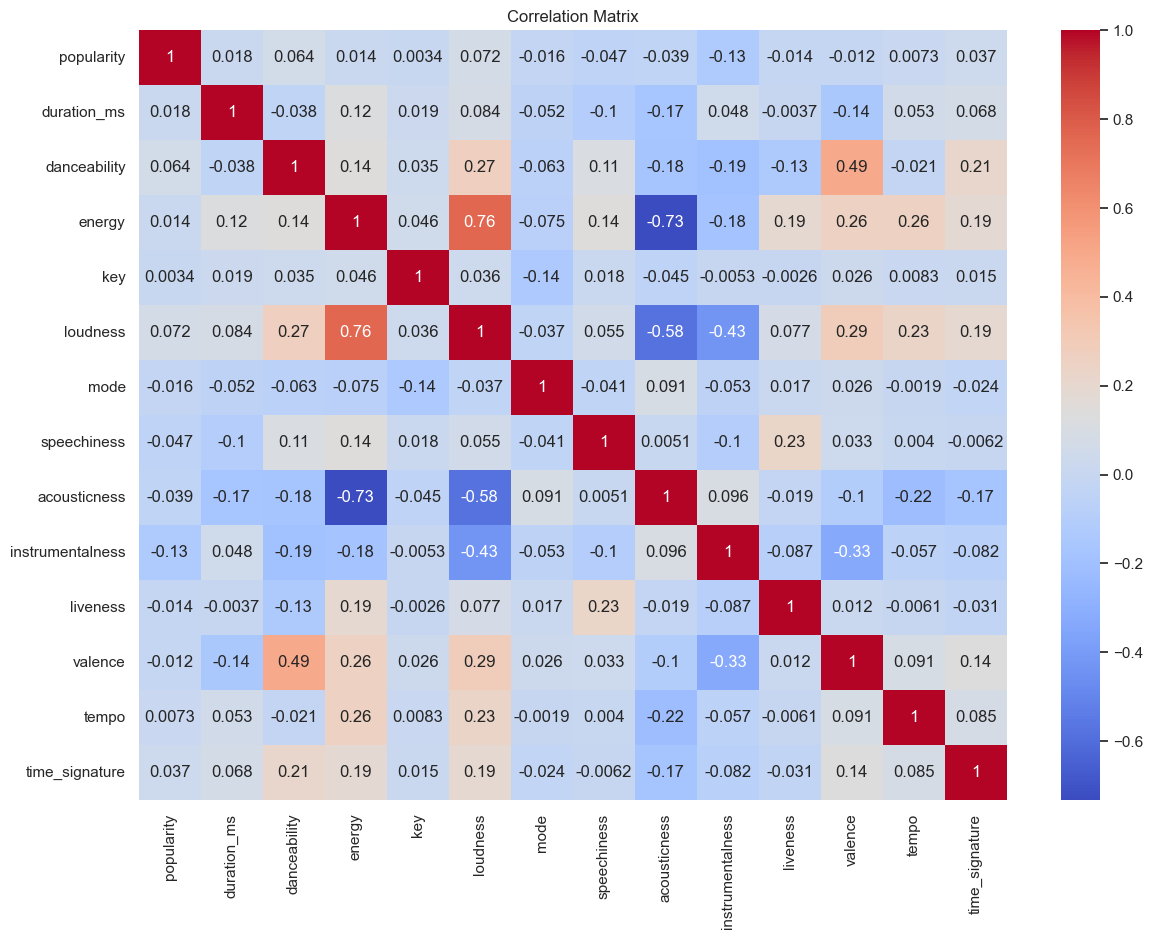

In [11]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

## Correlation with Popularity (Linear)

loudness            0.071676
danceability        0.064281
time_signature      0.036893
duration_ms         0.017802
energy              0.013728
tempo               0.007270
key                 0.003432
valence            -0.011526
liveness           -0.013844
mode               -0.016214
acousticness       -0.038847
speechiness        -0.047081
instrumentalness   -0.127465
Name: popularity, dtype: float64


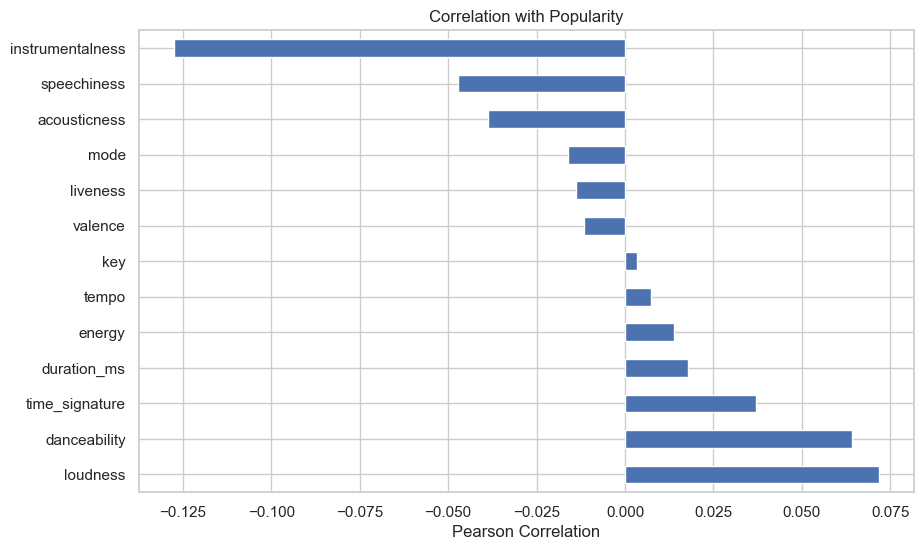

In [ ]:
corr_popularity = (
    df.select_dtypes(include=np.number)
      .corr()['popularity']
      .drop('popularity')
      .sort_values(ascending=False)
)

print(corr_popularity)

plt.figure(figsize=(10,6))
corr_popularity.plot(kind='barh')
plt.title("Correlation with Popularity")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.show()

##### We can observe that there are no linear audio characteristics correlations with popularity. These findings suggest that popularity is likely driven by complex interactions among multiple audio characteristics and genre-specific effects. Consequently, a nonlinear modeling approach such as a Multilayer Perceptron (MLP) may be better suited to capture these relationships than traditional linear models.

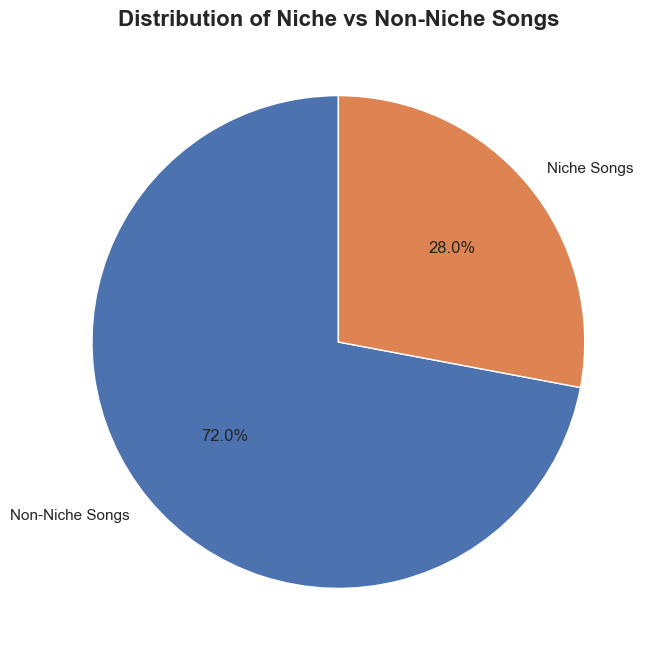

In [13]:
df['is_niche'] = (df['popularity'] <= 20)

counts = df['is_niche'].value_counts()

labels = [
    'Non-Niche Songs',
    'Niche Songs'
]

plt.figure(figsize=(8,8))

plt.pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    "Distribution of Niche vs Non-Niche Songs",
    fontsize=16,
    fontweight='bold'
)

plt.show()

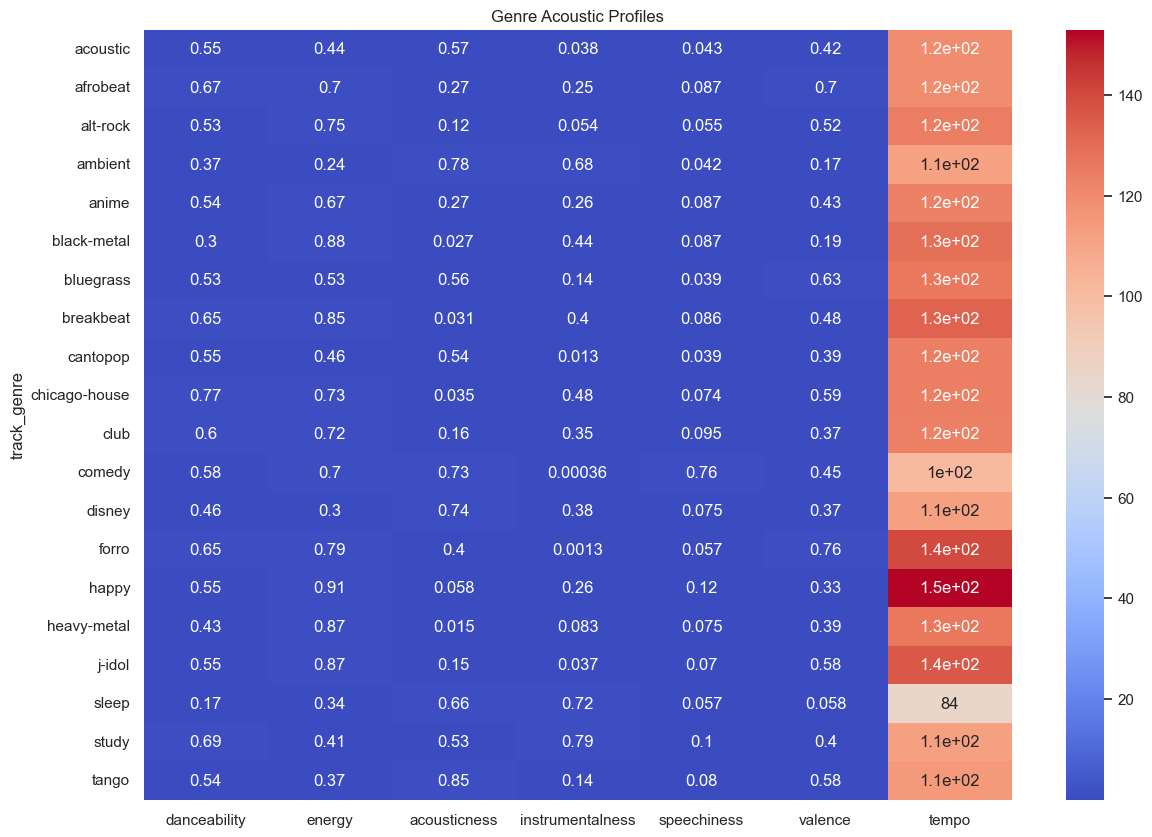

In [14]:
genre_profile = (
    df.groupby('track_genre')
    [
        [
            'danceability',
            'energy',
            'acousticness',
            'instrumentalness',
            'speechiness',
            'valence',
            'tempo'
        ]
    ]
    .mean()
)

top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
    .index
)

genre_profile = (
    df[df['track_genre'].isin(top_genres)]
    .groupby('track_genre')
    [
        [
            'danceability',
            'energy',
            'acousticness',
            'instrumentalness',
            'speechiness',
            'valence',
            'tempo'
        ]
    ]
    .mean()
)

plt.figure(figsize=(14,10))

sns.heatmap(
    genre_profile,
    cmap='coolwarm',
    annot=True
)

plt.title(
    "Genre Acoustic Profiles"
)

plt.show()

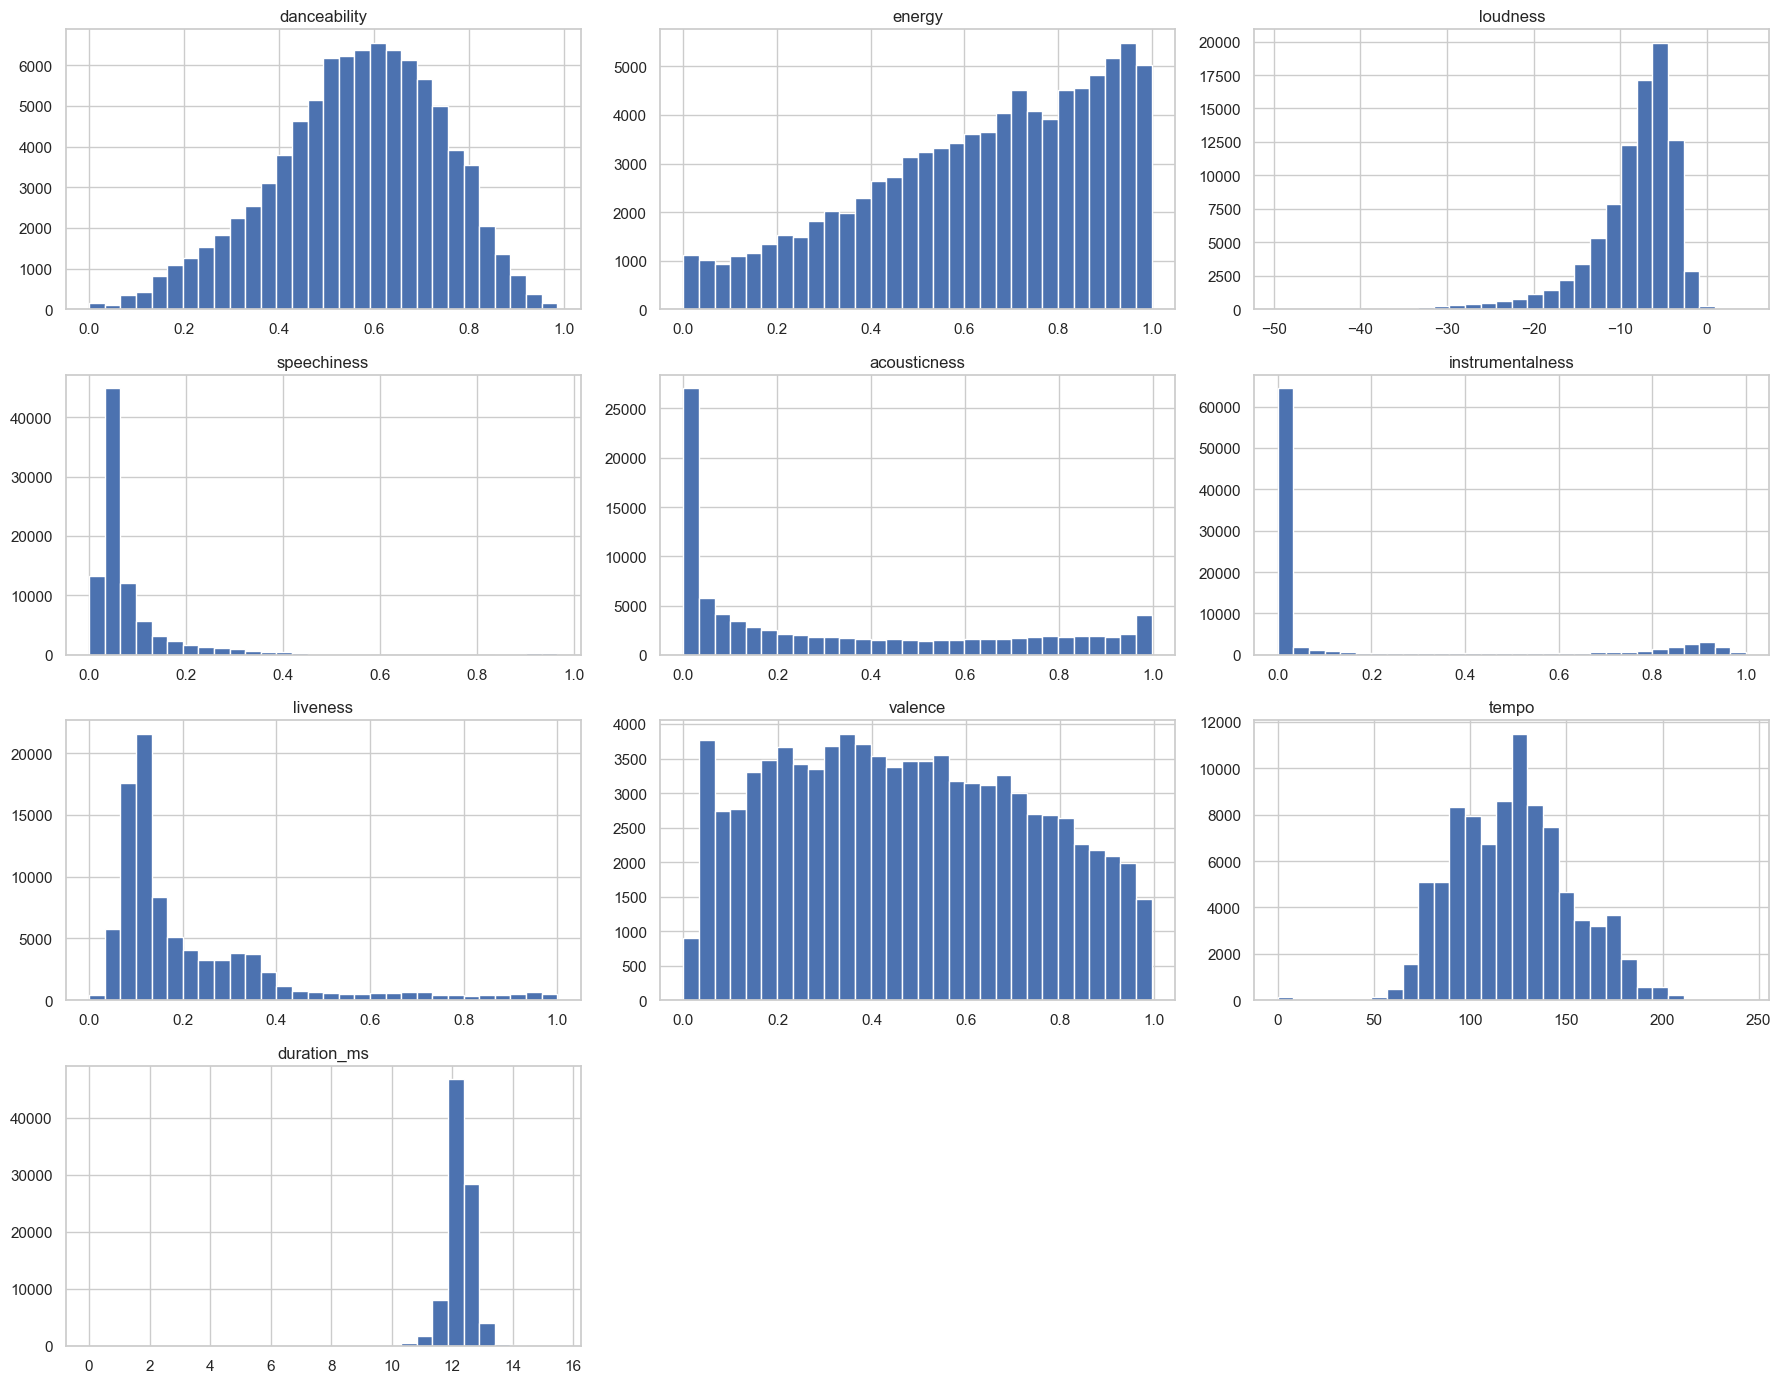

In [15]:
numeric_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

df[numeric_features].hist(
    bins=30,
    figsize=(18,14)
)

plt.tight_layout()

plt.show()